# Cardiac Patient Monitoring — Machine Learning Analysis

## Table of Contents
1. Setup & Imports
2. Load the Dataset
3. Initial Data Inspection
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Train/Test Split & Baseline Classification
7. Model Comparison
8. Cross-Validation
9. Feature Engineering
10. Scikit-learn Pipeline & Hyperparameter Tuning
11. Clustering / PCA (Unsupervised Analysis)
12. Final Findings & Limitations


# Cardiac Patient Monitoring System
## Machine Learning Classification Analysis

### Project Objective

The objective of this project is to build a machine learning classification workflow
using a cardiac-related dataset.

The analysis will cover:

- Data loading and inspection
- Data cleaning
- Exploratory Data Analysis (EDA)
- Statistical analysis
- Classification modeling
- Model comparison
- Cross-validation

The target variable is `target`, which represents the binary outcome in the dataset.

This project is an educational machine learning analysis and is not intended
for clinical diagnosis, treatment, or medical decision-making.

## 1. Setup & Imports <a id='1'></a>

Import the libraries used throughout the notebook (data handling, visualization, and Scikit-learn for modeling), silence non-critical warnings, set a consistent plot style, and fix a random seed so the results are reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## 2. Load the Dataset <a id='2'></a>

Load the cardiac dataset (`heart.csv`) into a pandas DataFrame.

In [2]:
df = pd.read_csv("../data/heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 3. Initial Data Inspection <a id='3'></a>

Get a first look at the data: the number of rows/columns, the column names, the data types, and summary statistics for each numerical column.

In [3]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 1025
Number of columns: 14


In [4]:
df.columns.tolist()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


### Target Variable

The target variable is `target`.

It is a binary classification target containing two classes:

- 0
- 1

The machine learning task is therefore formulated as a binary classification problem.

## 4. Data Cleaning <a id='4'></a>

### 4.1 Missing Values
Check every column for missing values before deciding how to handle them.

In [7]:
missing_values = df.isnull().sum()

missing_values

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing_summary

,Missing Values,Missing Percentage
age,0,0.0
sex,0,0.0
cp,0,0.0
trestbps,0,0.0
chol,0,0.0
fbs,0,0.0
restecg,0,0.0
thalach,0,0.0
exang,0,0.0
oldpeak,0,0.0


### 4.2 Duplicate Rows
Duplicate observations can bias the model and inflate performance metrics, so they are identified and removed.

In [9]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 723


In [10]:
original_shape = df.shape

print("Original shape:", original_shape)

Original shape: (1025, 14)


In [11]:
df = df.drop_duplicates().reset_index(drop=True)

In [12]:
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (302, 14)


In [13]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


### 4.3 Post-Cleaning Verification
Confirm there are no missing values left, and that the categorical columns only contain the expected set of values.

In [14]:
df.isnull().sum().sum()

np.int64(0)

In [15]:
categorical_columns = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal",
    "target"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(sorted(df[column].unique()))


sex:
[np.int64(0), np.int64(1)]

cp:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

fbs:
[np.int64(0), np.int64(1)]

restecg:
[np.int64(0), np.int64(1), np.int64(2)]

exang:
[np.int64(0), np.int64(1)]

slope:
[np.int64(0), np.int64(1), np.int64(2)]

ca:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

thal:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

target:
[np.int64(0), np.int64(1)]


In [16]:
df.shape

(302, 14)

In [17]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 5. Exploratory Data Analysis (EDA) <a id='5'></a>

### 5.1 Target Class Distribution
Examine the balance between the two target classes to decide whether stratified splitting is needed for modeling.

In [18]:
print(df["target"].value_counts())

target
1    164
0    138
Name: count, dtype: int64


In [19]:
print(df["target"].value_counts(normalize=True) * 100)

target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


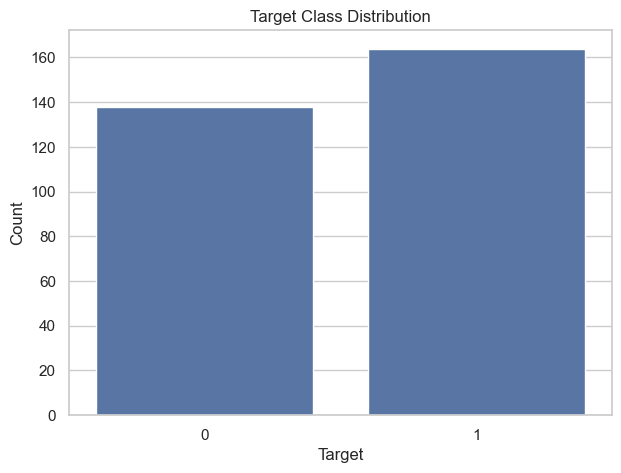

In [20]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="target")

plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

### Target Distribution

The target variable contains two classes: 0 and 1.

The class distribution was examined before modeling to determine whether
there is a significant class imbalance.

The dataset contains both classes, so stratified splitting will be used
during model development to preserve the class distribution.

### 5.2 Age Distribution

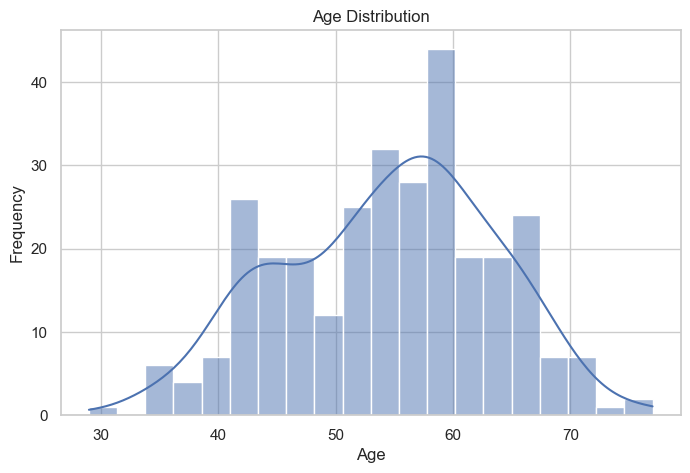

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

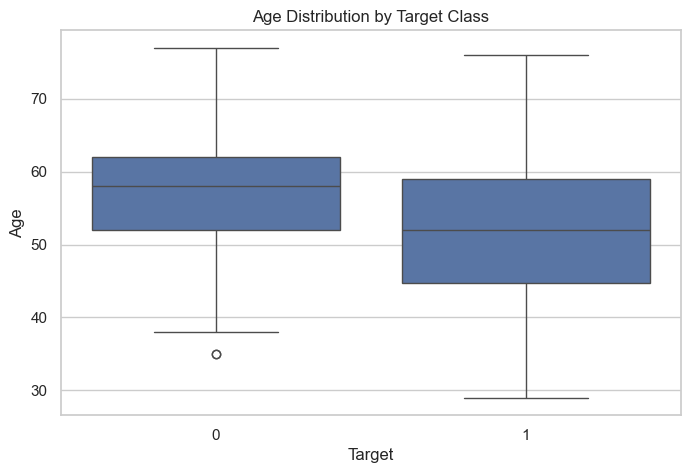

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="target",
    y="age"
)

plt.title("Age Distribution by Target Class")
plt.xlabel("Target")
plt.ylabel("Age")

plt.show()

### 5.3 Numerical Feature Distributions
Plot the distribution of each numerical feature to understand its shape and spread.

In [23]:
numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

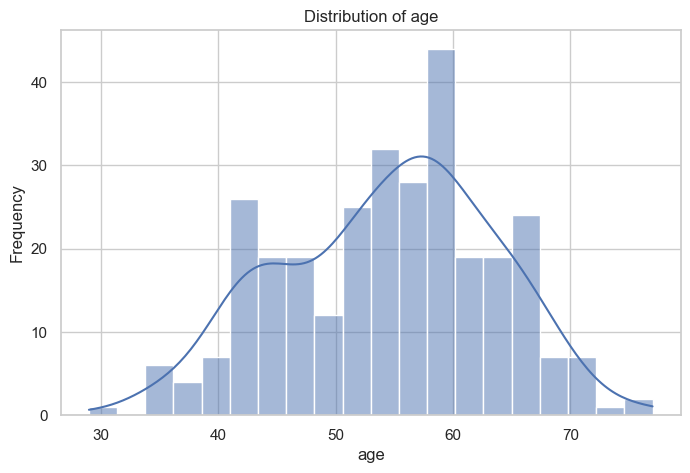

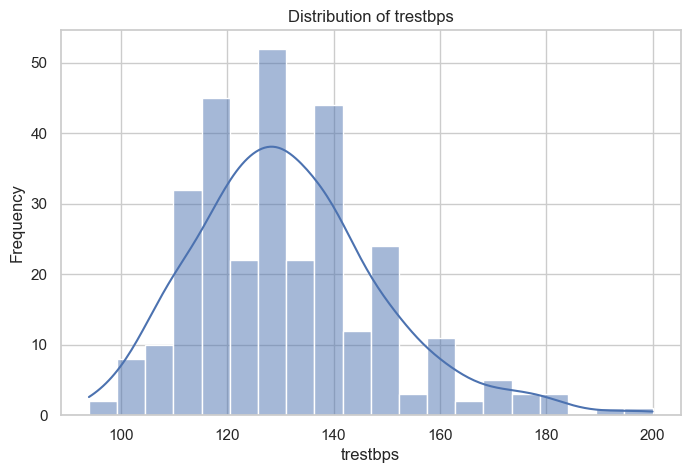

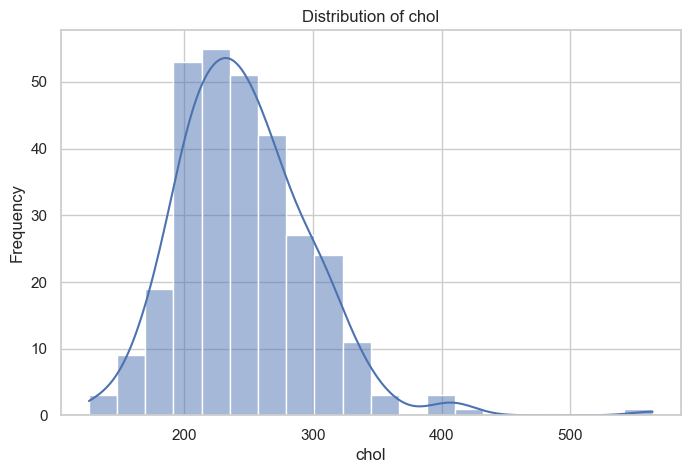

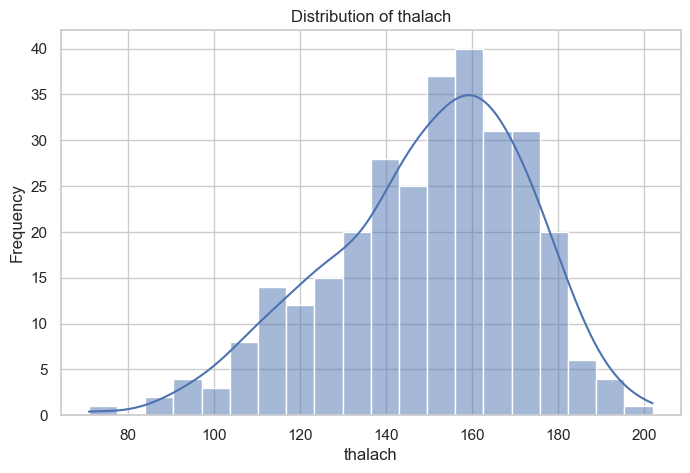

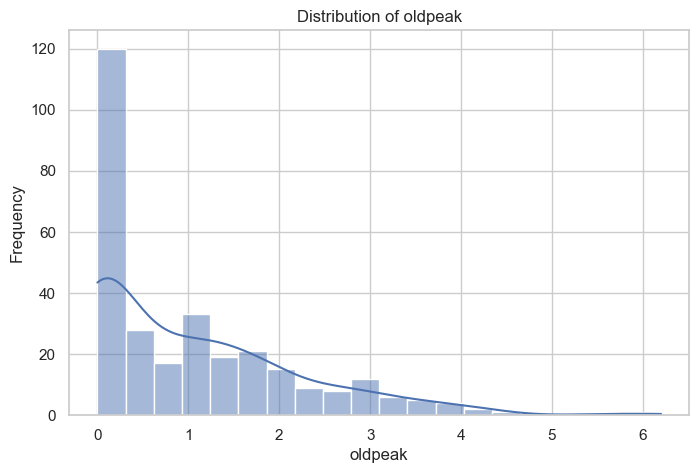

In [24]:
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=20
    )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    
    plt.show()

### 5.4 Categorical Feature Distributions
Compare how each categorical feature is distributed across the two target classes.

In [25]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

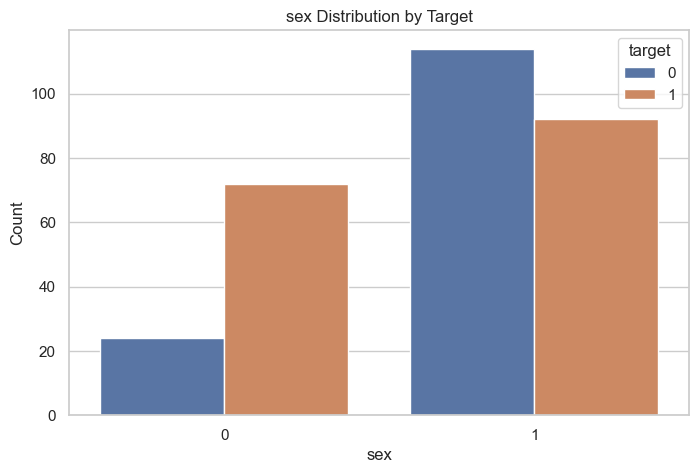

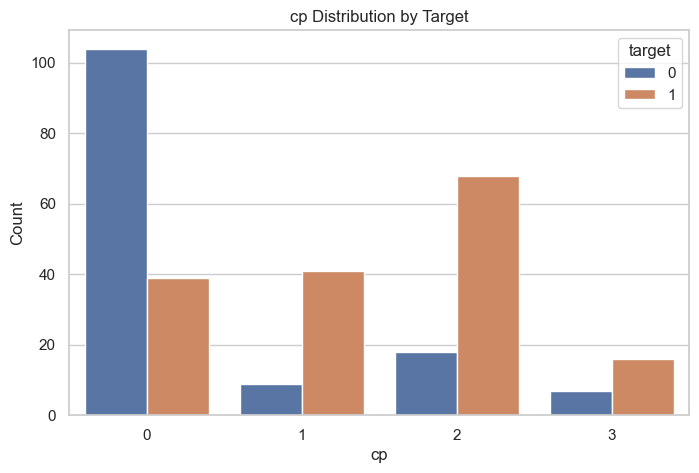

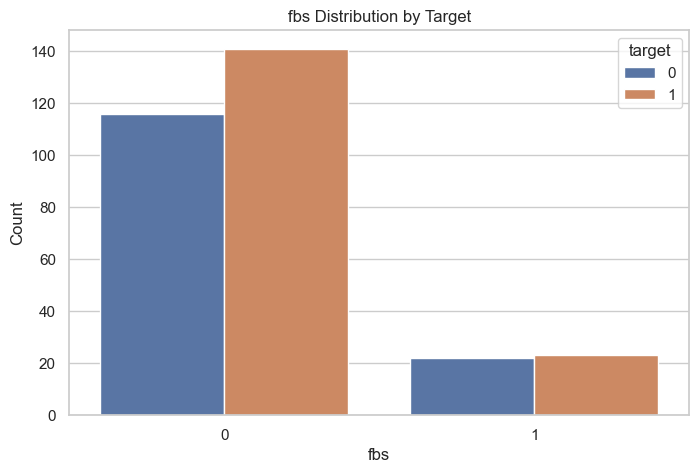

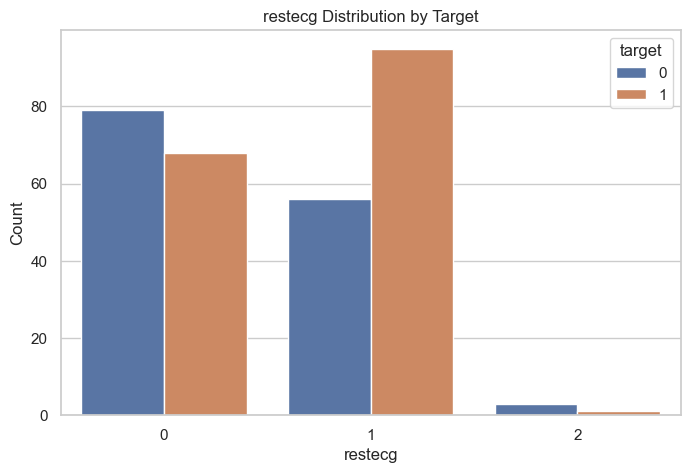

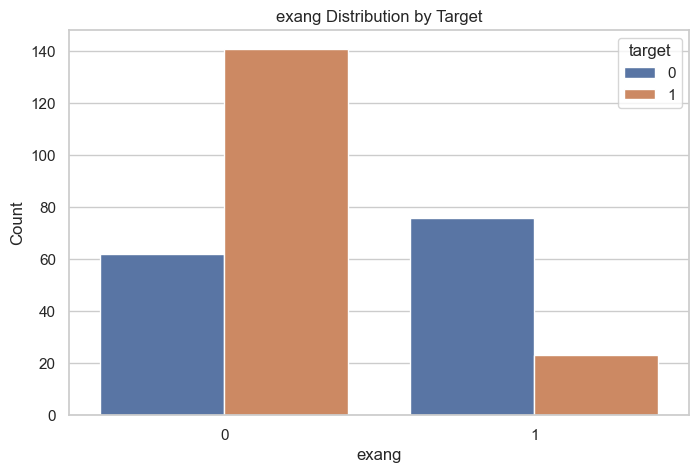

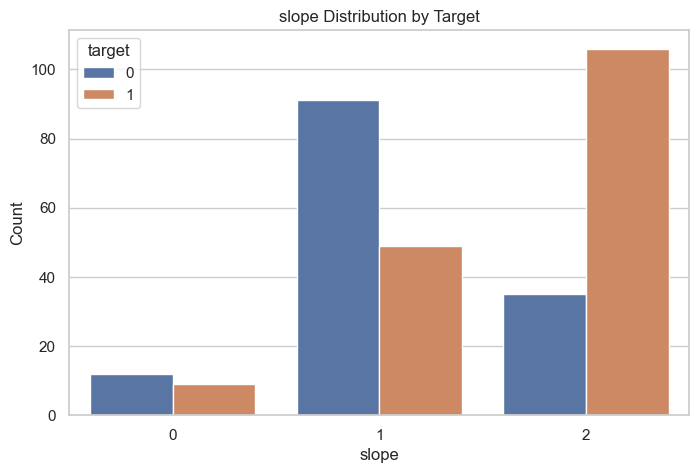

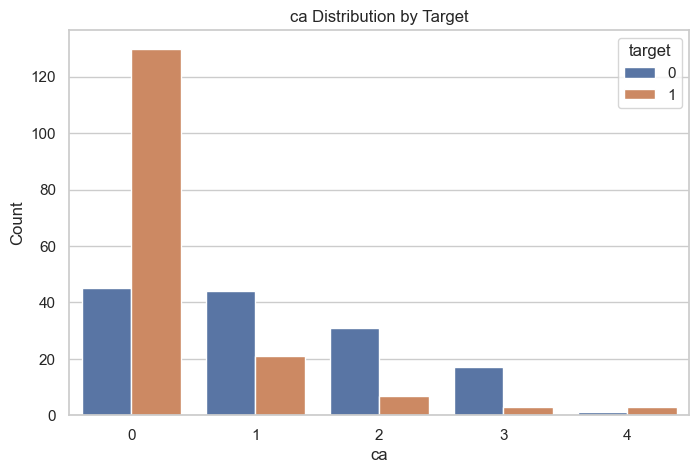

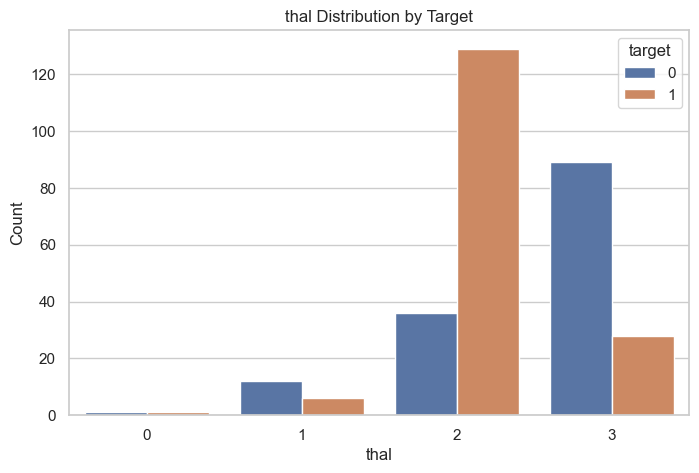

In [26]:
for column in categorical_features:
    plt.figure(figsize=(8, 5))
    
    sns.countplot(
        data=df,
        x=column,
        hue="target"
    )
    
    plt.title(f"{column} Distribution by Target")
    plt.xlabel(column)
    plt.ylabel("Count")
    
    plt.show()

### 5.5 Correlation Analysis
Compute pairwise correlations between all features and examine which features correlate most strongly with the target.

In [27]:
correlation_matrix = df.corr()

correlation_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


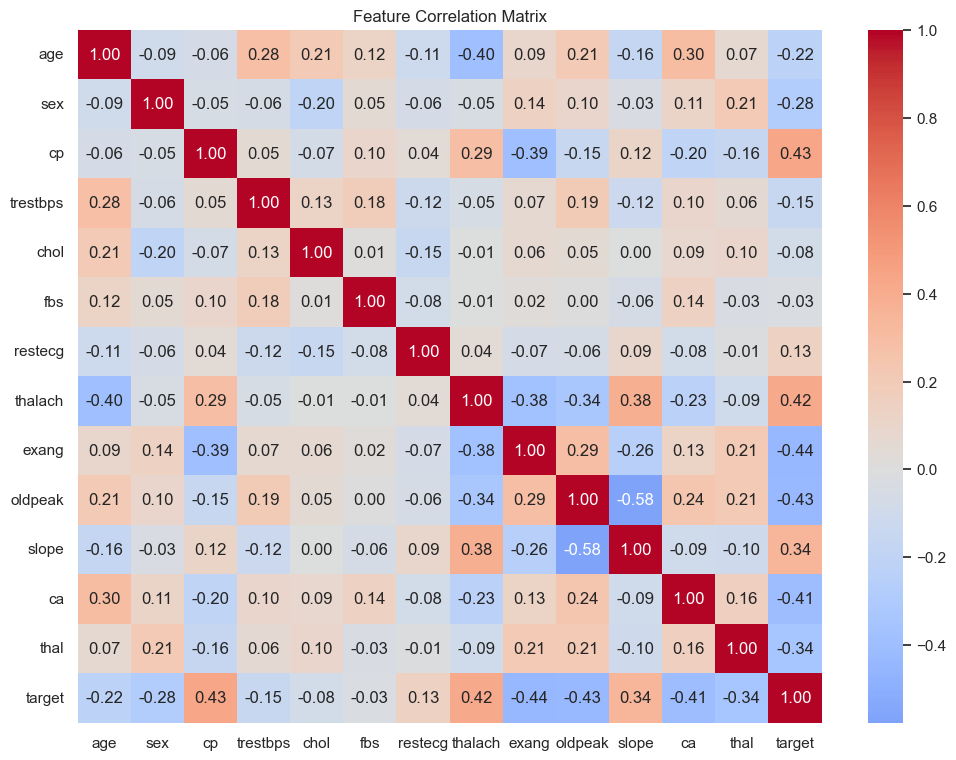

In [28]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

In [29]:
target_correlation = (
    df.corr()["target"]
    .sort_values(ascending=False)
)

target_correlation

target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64

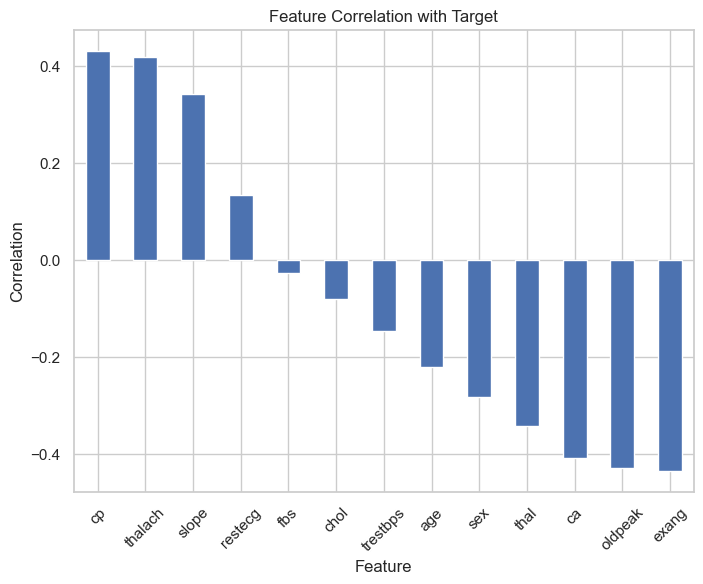

In [30]:
plt.figure(figsize=(8, 6))

target_correlation.drop("target").plot(
    kind="bar"
)

plt.title("Feature Correlation with Target")
plt.xlabel("Feature")
plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.show()

### 5.6 Outlier Detection
Use boxplots and the IQR method to flag potential outliers in the numerical features.

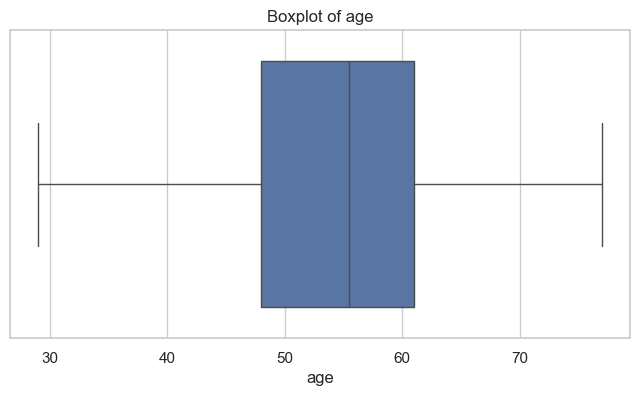

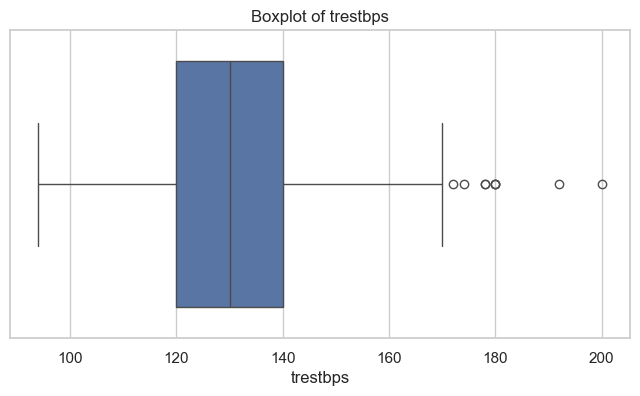

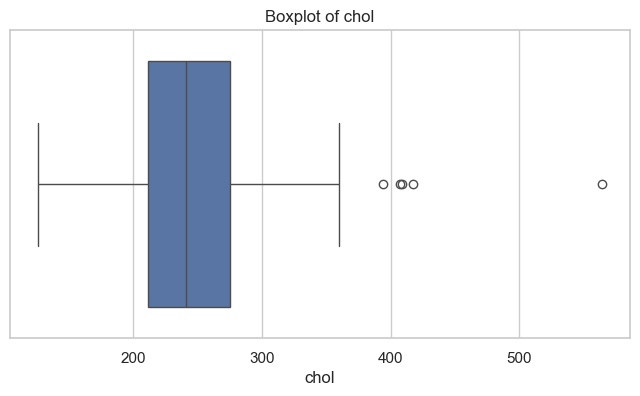

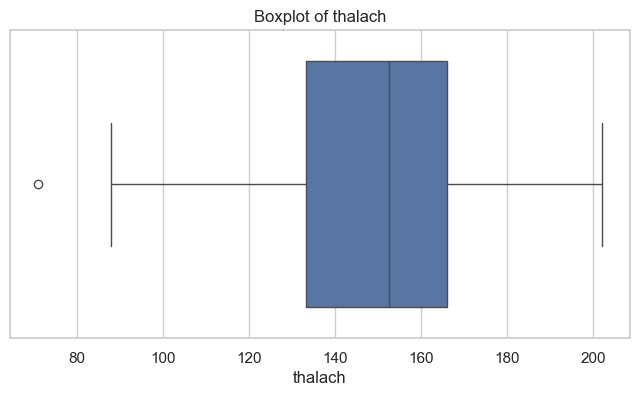

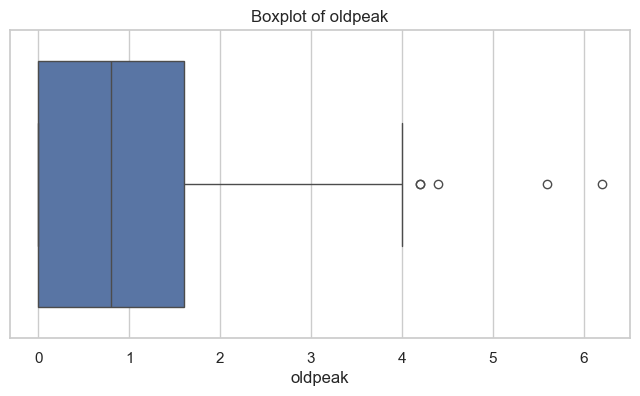

In [31]:
for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        data=df,
        x=column
    )
    
    plt.title(f"Boxplot of {column}")
    
    plt.show()

In [32]:
outlier_summary = {}

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    outlier_summary[column] = len(outliers)

outlier_summary

{'age': 0, 'trestbps': 9, 'chol': 5, 'thalach': 1, 'oldpeak': 5}

## 6. Train/Test Split & Baseline Classification <a id='6'></a>

### 6.1 Feature/Target Split & Train-Test Split
Separate the features (`X`) from the target (`y`), then split the data into training and test sets, stratifying on the target to preserve the class balance.

In [33]:
X = df.drop("target", axis=1)
y = df["target"]

In [34]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (302, 13)
y shape: (302,)


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

In [36]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (241, 13)
X_test: (61, 13)
y_train: (241,)
y_test: (61,)


### 6.2 Baseline Model: Logistic Regression
Train a simple, interpretable Logistic Regression pipeline (with feature scaling) as a baseline to compare more complex models against.

In [37]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

In [38]:
baseline_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [39]:
y_pred = baseline_model.predict(X_test)

In [40]:
y_proba = baseline_model.predict_proba(X_test)[:, 1]

In [41]:
baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_precision = precision_score(y_test, y_pred)
baseline_recall = recall_score(y_test, y_pred)
baseline_f1 = f1_score(y_test, y_pred)
baseline_roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {baseline_accuracy:.3f}")
print(f"Precision: {baseline_precision:.3f}")
print(f"Recall   : {baseline_recall:.3f}")
print(f"F1-Score : {baseline_f1:.3f}")
print(f"ROC-AUC  : {baseline_roc_auc:.3f}")

Accuracy : 0.803
Precision: 0.800
Recall   : 0.848
F1-Score : 0.824
ROC-AUC  : 0.871


In [42]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[21  7]
 [ 5 28]]


<Figure size 600x500 with 0 Axes>

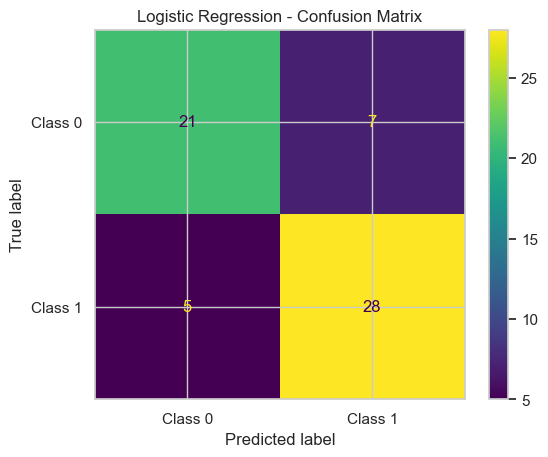

In [43]:
plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [44]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



## 7. Model Comparison <a id='7'></a>

Train several classifiers (Logistic Regression, Random Forest, SVM, and k-NN) on the same train/test split and compare them on Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [45]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            probability=True,
            random_state=RANDOM_STATE
        ))
    ]),

    "k-NN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ])
}

In [46]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, probabilities)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    })

In [47]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.803,0.800,0.848,0.824,0.871
1,k-NN,0.787,0.778,0.848,0.812,0.838
2,SVM,0.770,0.771,0.818,0.794,0.842
3,Random Forest,0.754,0.765,0.788,0.776,0.870


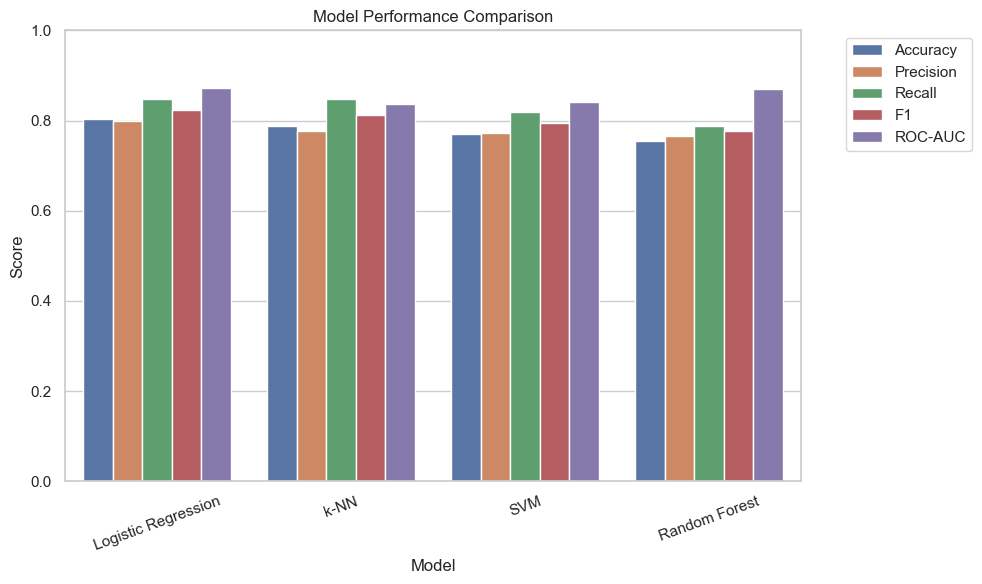

In [48]:
plt.figure(figsize=(10, 6))

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")

plt.xticks(rotation=20)

plt.ylim(0, 1)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

## 8. Cross-Validation <a id='8'></a>

A single train/test split can be misleading, so each model is re-evaluated using 5-fold stratified cross-validation, which gives a mean and standard deviation for every metric and a more reliable comparison between models.

In [49]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [50]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [51]:
cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,

        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),

        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),

        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),

        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "ROC-AUC Std": scores["test_roc_auc"].std()
    })

In [52]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df.round(3)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std
0,Logistic Regression,0.838,0.086,0.828,0.091,0.901,0.067,0.860,0.068,0.914,0.036
1,Random Forest,0.846,0.043,0.843,0.067,0.893,0.045,0.864,0.034,0.907,0.047
2,SVM,0.850,0.045,0.836,0.056,0.908,0.040,0.869,0.035,0.913,0.039
3,k-NN,0.830,0.049,0.839,0.069,0.863,0.052,0.847,0.037,0.901,0.026


In [53]:
best_model_cv = cv_results_df.loc[
    cv_results_df["F1 Mean"].idxmax()
]

best_model_cv

Model                  SVM
Accuracy Mean     0.850425
Accuracy Std      0.044932
Precision Mean     0.83637
Precision Std     0.055991
Recall Mean       0.907977
Recall Std        0.039617
F1 Mean             0.8691
F1 Std            0.034952
ROC-AUC Mean      0.913235
ROC-AUC Std       0.039131
Name: 2, dtype: object

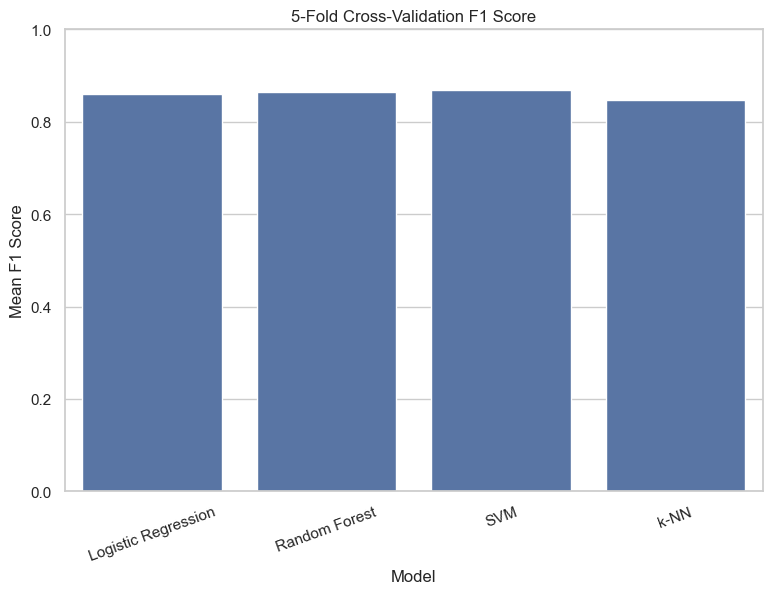

In [54]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=cv_results_df,
    x="Model",
    y="F1 Mean"
)

plt.title("5-Fold Cross-Validation F1 Score")
plt.xlabel("Model")
plt.ylabel("Mean F1 Score")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.show()

## 9. Feature Engineering <a id='9'></a>

Feature engineering is used to create additional representations of the existing variables that may help the model capture meaningful patterns.

Two engineered features are introduced:

1. `age_group`: groups patients into age ranges to represent age-related differences in a categorical form.
2. `stress_index`: combines exercise-induced angina (`exang`) with ST depression (`oldpeak`) to represent a simple cardiovascular stress-related signal.

In [55]:
def add_engineered_features(data):
    data = data.copy()

    data["age_group"] = pd.cut(
        data["age"],
        bins=[0, 40, 55, 70, np.inf],
        labels=["Young", "Middle", "Senior", "Older"]
    )

    data["stress_index"] = (
        data["oldpeak"] * (1 + data["exang"])
    )

    return data

In [56]:
df_engineered = add_engineered_features(df)

df_engineered.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,stress_index
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,Middle,1.0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,Middle,6.2
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,Senior,5.2
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,Senior,0.0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,Senior,1.9


In [57]:
print(df_engineered[[
    "age",
    "oldpeak",
    "exang",
    "age_group",
    "stress_index"
]].head(10))

   age  oldpeak  exang age_group  stress_index
0   52      1.0      0    Middle           1.0
1   53      3.1      1    Middle           6.2
2   70      2.6      1    Senior           5.2
3   61      0.0      0    Senior           0.0
4   62      1.9      0    Senior           1.9
5   58      1.0      0    Senior           1.0
6   58      4.4      0    Senior           4.4
7   55      0.8      1    Middle           1.6
8   46      0.8      0    Middle           0.8
9   54      3.2      1    Middle           6.4


In [58]:
print("Original number of features:", df.shape[1] - 1)
print("New number of features:", df_engineered.shape[1] - 1)

Original number of features: 13
New number of features: 15


## 10. Scikit-learn Pipeline & Hyperparameter Tuning <a id='10'></a>

### 10.1 Rebuild the Train/Test Split with Engineered Features
Redefine `X` and `y` using the engineered dataset and split it again into training and test sets.

In [59]:
X = df_engineered.drop("target", axis=1)
y = df_engineered["target"]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

### 10.2 Preprocessing + Logistic Regression Pipeline
Build a `ColumnTransformer` that scales numerical features and one-hot encodes categorical features, and wrap it together with Logistic Regression in a single `Pipeline`. Bundling preprocessing and modeling this way prevents information leakage from the test set during cross-validation.

In [61]:
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "stress_index"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal",
    "age_group"
]

In [62]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [63]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [64]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )
])

In [65]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
pipeline_predictions = pipeline.predict(X_test)

pipeline_probabilities = pipeline.predict_proba(X_test)[:, 1]

In [67]:
pipeline_accuracy = accuracy_score(
    y_test,
    pipeline_predictions
)

pipeline_precision = precision_score(
    y_test,
    pipeline_predictions
)

pipeline_recall = recall_score(
    y_test,
    pipeline_predictions
)

pipeline_f1 = f1_score(
    y_test,
    pipeline_predictions
)

pipeline_roc_auc = roc_auc_score(
    y_test,
    pipeline_probabilities
)

print(f"Accuracy : {pipeline_accuracy:.3f}")
print(f"Precision: {pipeline_precision:.3f}")
print(f"Recall   : {pipeline_recall:.3f}")
print(f"F1-Score : {pipeline_f1:.3f}")
print(f"ROC-AUC  : {pipeline_roc_auc:.3f}")

Accuracy : 0.836
Precision: 0.848
Recall   : 0.848
F1-Score : 0.848
ROC-AUC  : 0.907


### 10.3 Hyperparameter Tuning: Random Forest + GridSearchCV
Search over a grid of Random Forest hyperparameters using 5-fold stratified cross-validation, optimizing for F1-score, and compare the best tuned model against the Logistic Regression baseline.

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [69]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            random_state=RANDOM_STATE
        )
    )
])

In [70]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [71]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)

In [72]:
grid_search.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [73]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}


In [74]:
print(
    f"Best Cross-Validated F1: "
    f"{grid_search.best_score_:.3f}"
)

Best Cross-Validated F1: 0.885


In [75]:
best_pipeline = grid_search.best_estimator_

best_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [76]:
grid_results = pd.DataFrame(
    grid_search.cv_results_
)

In [77]:
grid_results[
    [
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_split",
        "param_model__min_samples_leaf",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,mean_test_score,std_test_score,rank_test_score
2,100,None,5,1,0.885198,0.043191,1
18,100,10,5,1,0.885198,0.043191,1
10,100,5,5,1,0.883138,0.050712,3
8,100,5,2,1,0.879845,0.048688,4
16,100,10,2,1,0.877128,0.041709,5
3,200,None,5,1,0.875792,0.045417,6
19,200,10,5,1,0.875792,0.045417,6
6,100,None,5,2,0.874764,0.050896,8
22,100,10,5,2,0.874764,0.050896,8
17,200,10,2,1,0.873633,0.036406,10


In [78]:
baseline_f1_cv = cv_results_df.loc[
    cv_results_df["Model"] == "Logistic Regression",
    "F1 Mean"
].iloc[0]

tuned_f1_cv = grid_search.best_score_

print(f"Baseline CV F1: {baseline_f1_cv:.3f}")
print(f"Tuned RF CV F1: {tuned_f1_cv:.3f}")

Baseline CV F1: 0.860
Tuned RF CV F1: 0.885


In [79]:
improvement = tuned_f1_cv - baseline_f1_cv

print(f"F1 improvement: {improvement:.3f}")

F1 improvement: 0.025


### Hyperparameter Tuning Result

GridSearchCV was used to search for the best Random Forest
hyperparameter combination using 5-fold stratified cross-validation.

The tuned model is compared against the Logistic Regression baseline
using the same F1-score metric.

The comparison helps determine whether model complexity and
hyperparameter optimization provide a measurable improvement.

### 10.4 Final Model Evaluation
Evaluate the tuned Random Forest pipeline on the held-out test set.

In [80]:
final_predictions = best_pipeline.predict(X_test)

final_probabilities = best_pipeline.predict_proba(
    X_test
)[:, 1]

In [81]:
final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions
)

final_recall = recall_score(
    y_test,
    final_predictions
)

final_f1 = f1_score(
    y_test,
    final_predictions
)

final_roc_auc = roc_auc_score(
    y_test,
    final_probabilities
)

print("FINAL MODEL PERFORMANCE")
print("-" * 30)

print(f"Accuracy : {final_accuracy:.3f}")
print(f"Precision: {final_precision:.3f}")
print(f"Recall   : {final_recall:.3f}")
print(f"F1-Score : {final_f1:.3f}")
print(f"ROC-AUC  : {final_roc_auc:.3f}")

FINAL MODEL PERFORMANCE
------------------------------
Accuracy : 0.770
Precision: 0.788
Recall   : 0.788
F1-Score : 0.788
ROC-AUC  : 0.876


In [82]:
final_cm = confusion_matrix(
    y_test,
    final_predictions
)

print(final_cm)

[[21  7]
 [ 7 26]]


<Figure size 600x500 with 0 Axes>

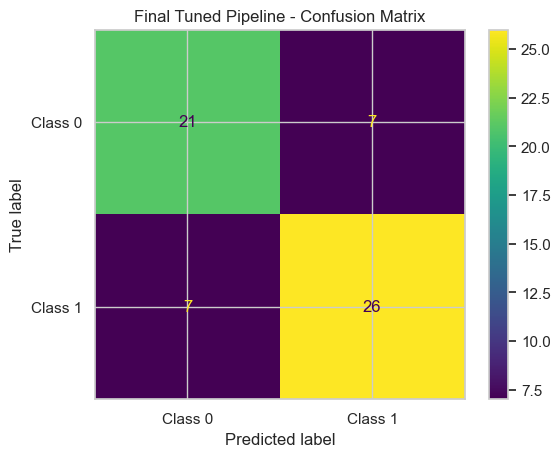

In [83]:
plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Class 0", "Class 1"]
).plot()

plt.title("Final Tuned Pipeline - Confusion Matrix")

plt.show()

### Confusion Matrix Interpretation

A False Positive occurs when the model predicts class 1 while the actual
class is 0.

A False Negative occurs when the model predicts class 0 while the actual
class is 1.

In this educational project, these errors are analyzed as classification
errors only. The model must not be interpreted as a clinical diagnostic
system.

In [84]:
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "Class 0",
            "Class 1"
        ]
    )
)

              precision    recall  f1-score   support

     Class 0       0.75      0.75      0.75        28
     Class 1       0.79      0.79      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



### 10.5 Feature Importance
Inspect which features the tuned Random Forest relies on most, after the one-hot encoding step.

In [85]:
feature_names = (
    best_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [86]:
importances = (
    best_pipeline
    .named_steps["model"]
    .feature_importances_
)

In [87]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

In [88]:
feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

In [89]:
feature_importance_df.head(15)

,Feature,Importance
8,cat__cp_0,0.133071
5,num__stress_index,0.102908
3,num__thalach,0.079786
29,cat__thal_2,0.066844
22,cat__ca_0,0.066114
30,cat__thal_3,0.059023
4,num__oldpeak,0.054016
18,cat__exang_1,0.052106
2,num__chol,0.044563
1,num__trestbps,0.044237


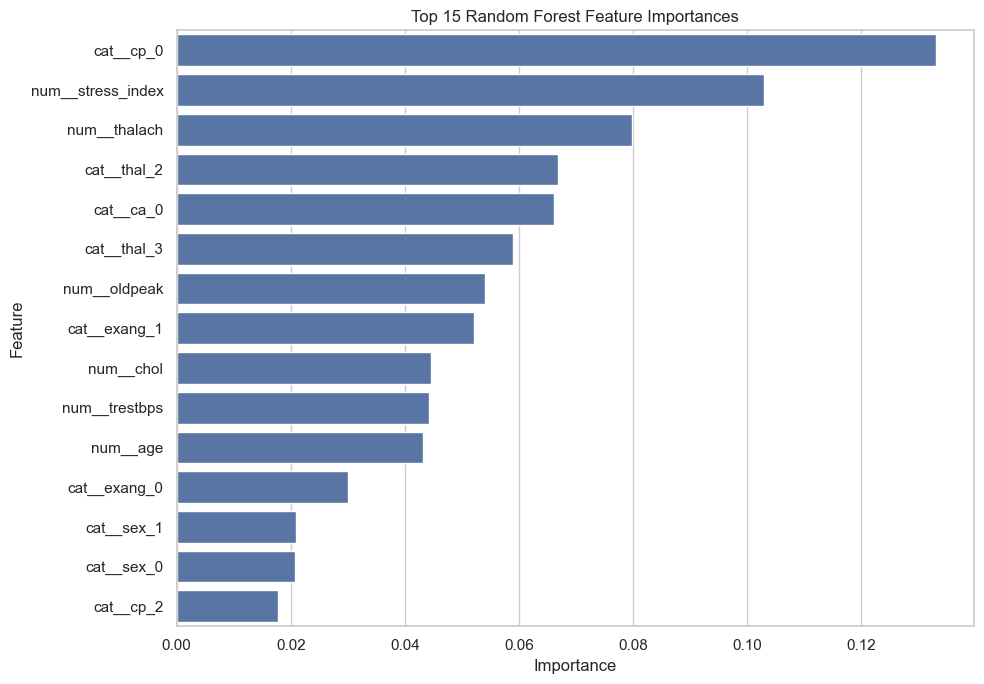

In [90]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Feature Importances")

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

## 11. Clustering / PCA (Unsupervised Analysis) <a id='11'></a>

### 11.1 Prepare Data for Unsupervised Learning
Preprocess the feature set (without the target) the same way as before, so it can be used for clustering and dimensionality reduction.

In [91]:
X_unsupervised = df_engineered.drop(
    "target",
    axis=1
)

In [92]:
unsupervised_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [93]:
X_unsupervised_processed = (
    unsupervised_preprocessor.fit_transform(
        X_unsupervised
    )
)

In [94]:
print(
    "Processed shape:",
    X_unsupervised_processed.shape
)

Processed shape: (302, 35)


### 11.2 Choosing the Number of Clusters (Silhouette Score)
Run K-Means for a range of cluster counts and use the silhouette score to pick the number of clusters that best separates the data.

In [95]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [96]:
k_values = range(2, 8)

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_unsupervised_processed
    )

    score = silhouette_score(
        X_unsupervised_processed,
        labels
    )

    silhouette_scores.append(score)

In [97]:
cluster_results = pd.DataFrame({
    "K": list(k_values),
    "Silhouette Score": silhouette_scores
})

cluster_results

,K,Silhouette Score
0,2,0.193962
1,3,0.146745
2,4,0.130998
3,5,0.128295
4,6,0.100161
5,7,0.086029


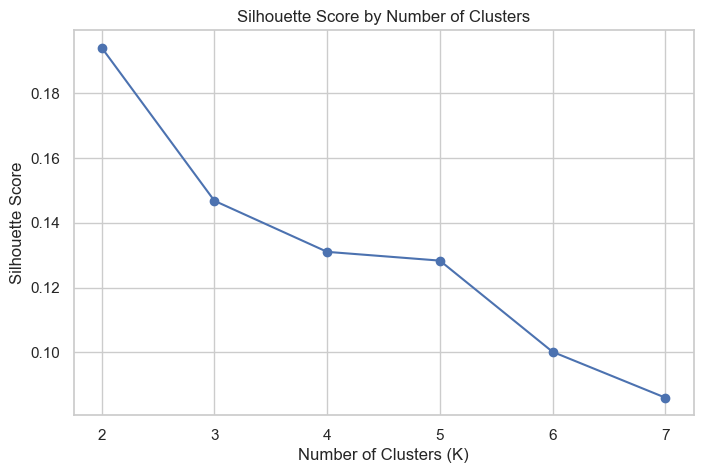

In [98]:
plt.figure(figsize=(8, 5))

plt.plot(
    cluster_results["K"],
    cluster_results["Silhouette Score"],
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.show()

In [99]:
best_k = cluster_results.loc[
    cluster_results["Silhouette Score"].idxmax(),
    "K"
]

print("Best K:", best_k)

Best K: 2


### 11.3 Applying K-Means
Fit K-Means with the chosen number of clusters and attach the cluster labels back to the dataset.

In [100]:
kmeans = KMeans(
    n_clusters=int(best_k),
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_labels = kmeans.fit_predict(
    X_unsupervised_processed
)

In [101]:
df_clustered = df_engineered.copy()

df_clustered["cluster"] = cluster_labels

In [102]:
df_clustered[
    [
        "age",
        "sex",
        "cp",
        "thalach",
        "oldpeak",
        "target",
        "cluster"
    ]
].head()

,age,sex,cp,thalach,oldpeak,target,cluster
0,52,1,0,168,1.0,0,0
1,53,1,0,155,3.1,0,1
2,70,1,0,125,2.6,0,1
3,61,1,0,161,0.0,0,0
4,62,0,0,106,1.9,0,1


In [103]:
cluster_counts = (
    df_clustered["cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts

cluster
0    187
1    115
Name: count, dtype: int64

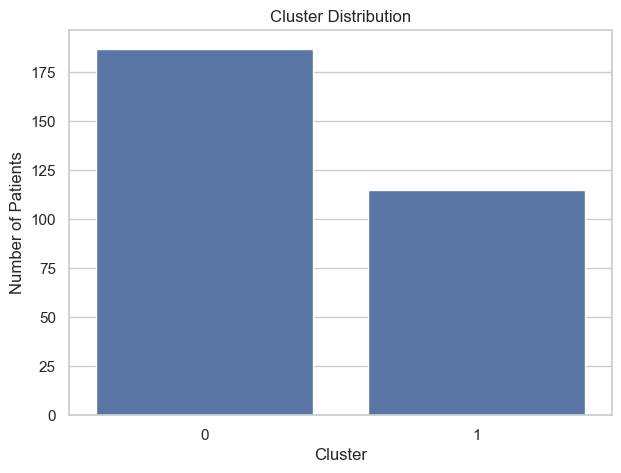

In [104]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clustered,
    x="cluster"
)

plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Patients")

plt.show()

### 11.4 PCA Dimensionality Reduction
Project the processed features into two principal components to visualize the clusters and the target classes in 2D.

In [105]:
from sklearn.decomposition import PCA

In [106]:
pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_pca = pca.fit_transform(
    X_unsupervised_processed
)

In [107]:
print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio: [0.27675551 0.1360006 ]
Total explained variance: 0.412756108976823


In [108]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": cluster_labels
})

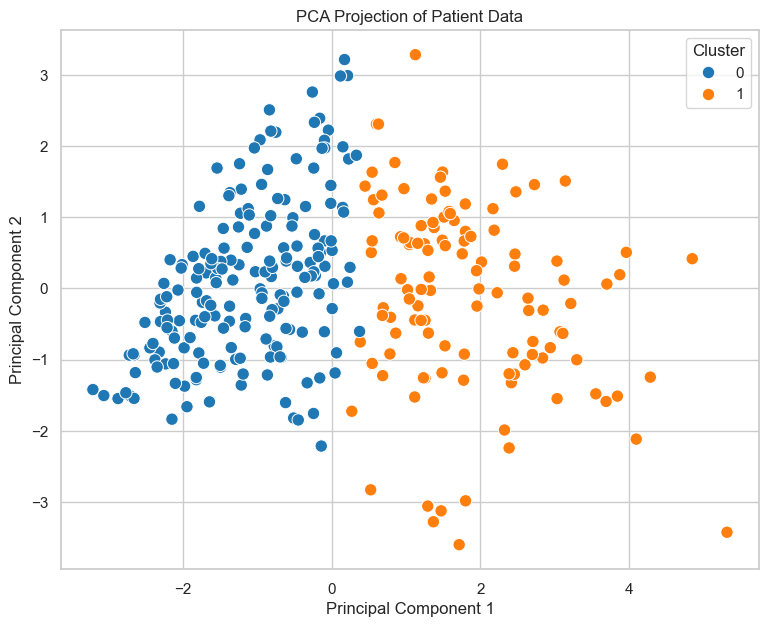

In [109]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=80
)

plt.title("PCA Projection of Patient Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [110]:
pca_df["Target"] = df_engineered["target"].values

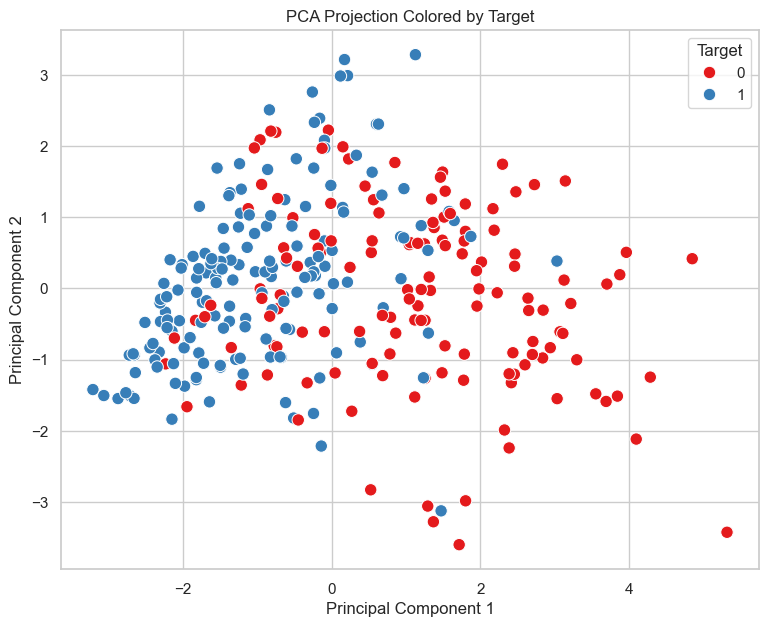

In [111]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="Set1",
    s=80
)

plt.title("PCA Projection Colored by Target")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

### 11.5 Cluster vs. Target Relationship
Check how the target classes are distributed within each cluster, purely as a descriptive comparison (the clusters were built without using the target).

In [112]:
cluster_target_distribution = pd.crosstab(
    df_clustered["cluster"],
    df_clustered["target"],
    normalize="index"
)

cluster_target_distribution

target,0,1
cluster,,
0,0.235294,0.764706
1,0.817391,0.182609


In [113]:
(
    cluster_target_distribution * 100
).round(2)

target,0,1
cluster,,
0,23.53,76.47
1,81.74,18.26


## 12. Final Findings & Limitations <a id='12'></a>

Summarize the final tuned pipeline's performance and compare it against the baseline before wrapping up with the project's key takeaways and limitations.

In [114]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    
    "Final Tuned Pipeline": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})

final_results.round(3)

,Metric,Final Tuned Pipeline
0,Accuracy,0.770
1,Precision,0.788
2,Recall,0.788
3,F1-Score,0.788
4,ROC-AUC,0.876


In [115]:
comparison_final = pd.DataFrame({
    "Model": [
        "Logistic Regression Baseline",
        "Tuned Random Forest Pipeline"
    ],
    
    "F1 Score": [
        baseline_f1_cv,
        final_f1
    ]
})

comparison_final

,Model,F1 Score
0,Logistic Regression Baseline,0.860019
1,Tuned Random Forest Pipeline,0.787879


# Final Findings

## 1. Data Quality

The dataset initially contained duplicate observations.
Duplicate records were removed before modeling, resulting in a cleaner
dataset with 302 unique observations.

No missing values were identified in the selected dataset.

## 2. Exploratory Data Analysis

EDA was used to examine:

- Target class distribution
- Numerical feature distributions
- Categorical feature distributions
- Feature correlations
- Potential outliers

The analysis provided an understanding of the dataset before model training.

## 3. Supervised Learning

Logistic Regression was used as the baseline classifier.

Additional classifiers were evaluated using the same train/test methodology,
including Random Forest, SVM, and k-NN.

## 4. Cross-Validation

Stratified 5-fold cross-validation was used to obtain more reliable estimates
of model performance.

Both the mean and standard deviation of the evaluation metrics were examined.

## 5. Feature Engineering

Two additional features were created:

- `age_group`
- `stress_index`

These features were designed to provide additional representations of
existing information without using the target variable.

## 6. Hyperparameter Tuning

GridSearchCV was used to tune the Random Forest pipeline using 5-fold
cross-validation and F1-score as the optimization metric.

## 7. Final Pipeline

The final workflow combines feature preprocessing, categorical encoding,
numerical scaling, and Random Forest classification inside a single
Scikit-learn Pipeline.

This structure helps prevent preprocessing leakage during cross-validation.

## 8. Unsupervised Analysis

K-Means clustering was applied without using the target variable.

PCA was then used to project the processed feature space into two dimensions
for visualization.

The resulting clusters were examined in relation to the target only after
the unsupervised analysis had been completed.

## 9. Limitation

This project is an educational machine-learning analysis.

The results should not be interpreted as clinical diagnosis,
treatment recommendations, or medical decision-making.